# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [20]:
df = pd.read_csv("../../datasets/raw/Mod_18/ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [21]:
#Verificando o tipo de dados
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

#Na saída acima, constamos que todas as varíáveis são do tipo numérica (int64). Portando, náo exigirá nenhuma conversão.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [23]:
#Verificando a presença de Outliers

df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [22]:
#Verificando se existem dados nulos

df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

#Conforme a saída do comando acima, podemos constatar que não há valores ausentes ou nulos. Portanto, não será necessário realizarmos substituição ou remoção de registros por dados faltantes.

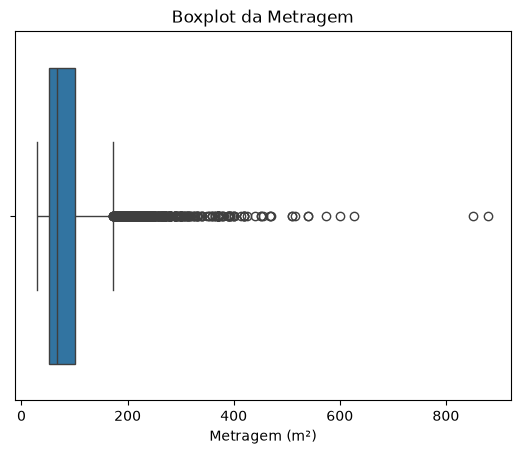

In [28]:
sns.boxplot(x=df['Metragem'])
plt.title('Boxplot da Metragem')
plt.xlabel('Metragem (m²)')
plt.show()

In [ ]:
#No gráfico bloxplot, podemos ver possíveis outlier principalmente acima de 170m2. Para descobrirmos a quantidades de possiveis imóveis Outliers, iremos utilizar a regra de IQR.

In [ ]:
#Aplicando a regra de IQR (fórmula IQR = Q3 − Q1) na variável metragem
Q1 = df['Metragem'].quantile(0.25)
Q3 = df['Metragem'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Q1: 52.0
Q3: 100.0
IQR: 48.0
Limite inferior: -20.0
Limite superior: 172.0


In [ ]:
# agor airemos contar quantos imóveis estão acima do limite superior:
outliers_metragem = df[df['Metragem'] > limite_superior]

print("Quantidade de possíveis outliers:", len(outliers_metragem))

Quantidade de possíveis outliers: 647


#Como se trata de uma quntidade grande de Outliers, decidi por não excluí-los no momento. Isso porque o IQR nos mostra que esses valores estão muito afastados da região central da distribuição. No entando, ele não diz que esses registros estão errados.

In [ ]:
# Verificando quais são os possíveis imóvies Outliers:
outliers_metragem[['Metragem', 'Valor_Aluguel']].sort_values('Metragem').tail(20)

,Metragem,Valor_Aluguel
6948,420,10000
6985,420,11000
7131,425,16000
6477,440,6000
6922,452,10000
7110,452,15000
7109,456,15000
7174,469,20000
7173,469,20000
7176,470,20000


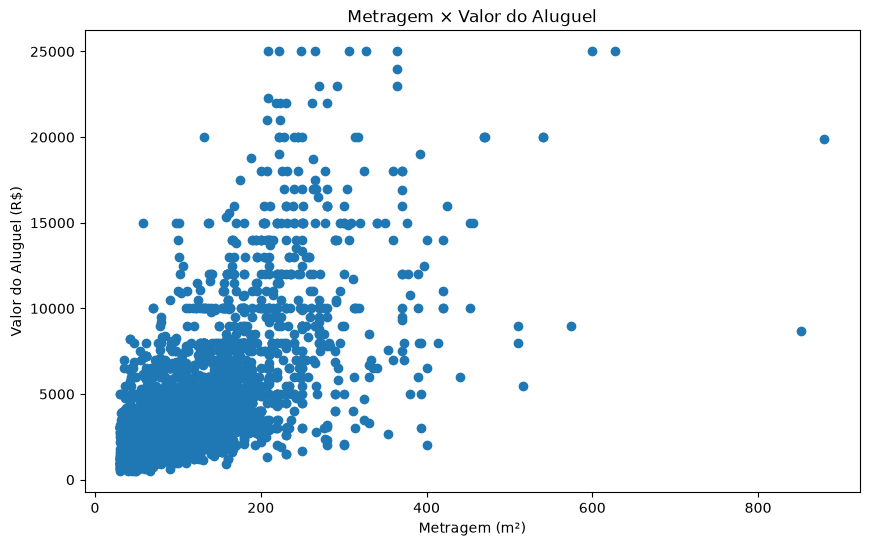

In [ ]:
#Gráfico Metragem × Valor do Aluguel
#Relação entre a metragem do imóvel e o valor do aluguel.

plt.figure(figsize=(10, 6))

plt.scatter(df['Metragem'], df['Valor_Aluguel'])

plt.title('Metragem × Valor do Aluguel')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel (R$)')

plt.show()

In [ ]:
#Analisando o gráfico acima, observamos que: imóveis maiores tendem a apresentar aluguéis mais altos, o que indica uma correlação positiva entre Metragem e Valor_Aluguelsaída.

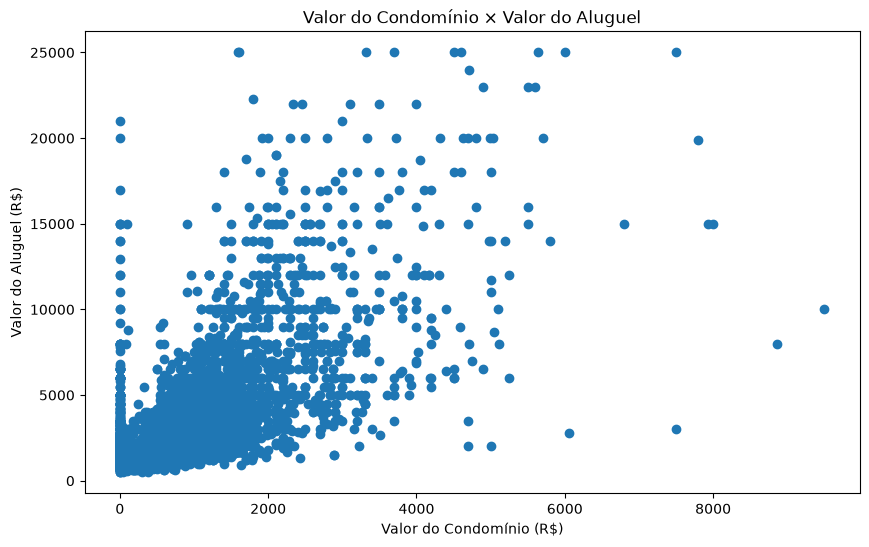

In [37]:
#Valor do Condomínio × Valor do Aluguel
#Relação entre o valor do condomínio e o valor do aluguel.

plt.figure(figsize=(10, 6))

plt.scatter(df['Valor_Condominio'], df['Valor_Aluguel'])

plt.title('Valor do Condomínio × Valor do Aluguel')
plt.xlabel('Valor do Condomínio (R$)')
plt.ylabel('Valor do Aluguel (R$)')

plt.show()

In [ ]:
# No gráfico acima, podemos ver que aluguéis mais altos estão associados a condomínios mais caros.

In [ ]:
# Antes de tomar a decisão definitiva, irei analizar os 10 maiores imóveis completos, e não somente Metragem e Valor_Aluguel. Dessa forma, conseguiremos verificar se existem erros de cadastro ou os valores são realmente plausíveis.
df.nlargest(10, 'Metragem')

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7166,19900,7800,880,5,4,5,6
6841,8700,5040,852,7,6,5,6
7198,25000,7500,627,4,5,4,6
7201,25000,6000,600,4,5,4,8
6862,9000,2280,574,4,1,4,5
7171,20000,4690,540,4,3,2,4
7172,20000,5030,540,4,3,2,4
6382,5500,2750,516,4,5,4,4
6786,8000,4200,510,6,5,4,3
6853,9000,4583,510,5,5,4,3


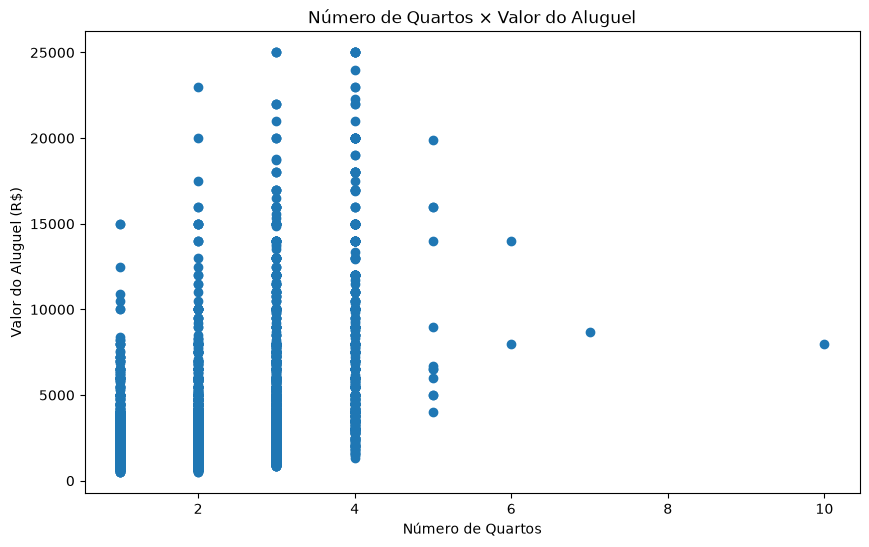

In [36]:
#Número de Quartos × Valor do Aluguel
#Relação entre o número de quartos do imóvel e o valor do aluguel.

plt.figure(figsize=(10, 6))

plt.scatter(df['N_Quartos'], df['Valor_Aluguel'])

plt.title('Número de Quartos × Valor do Aluguel')
plt.xlabel('Número de Quartos')
plt.ylabel('Valor do Aluguel (R$)')

plt.show()

Conclusão sobre os possíveis outliers de Metragem

A análise pelo método do IQR identificou valores de Metragem acima de 172 m² como possíveis outliers, totalizando 647 registros, aproximadamente 8,98% da base. Entretanto, a análise dos maiores imóveis mostrou coerência entre a metragem e outras características, como número de quartos, banheiros, suítes e vagas. Dessa forma, não há evidências suficientes de que esses valores sejam erros de cadastro. Optou-se, portanto, por manter os registros na base, evitando a remoção de uma parcela significativa dos dados que pode representar imóveis reais de maior porte.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




In [61]:
#Verificando a presença de Outliers
correlacao = df.corr()

correlacao


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
Valor_Aluguel,1.000000,0.695302,0.730591,0.413139,0.603715,0.614397,0.652858
Valor_Condominio,0.695302,1.000000,0.805926,0.497420,0.585795,0.589244,0.690993
Metragem,0.730591,0.805926,1.000000,0.678091,0.687558,0.696281,0.743872
N_Quartos,0.413139,0.497420,0.678091,1.000000,0.553807,0.540887,0.591224
N_banheiros,0.603715,0.585795,0.687558,0.553807,1.000000,0.920149,0.694983
N_Suites,0.614397,0.589244,0.696281,0.540887,0.920149,1.000000,0.712054
N_Vagas,0.652858,0.690993,0.743872,0.591224,0.694983,0.712054,1.000000


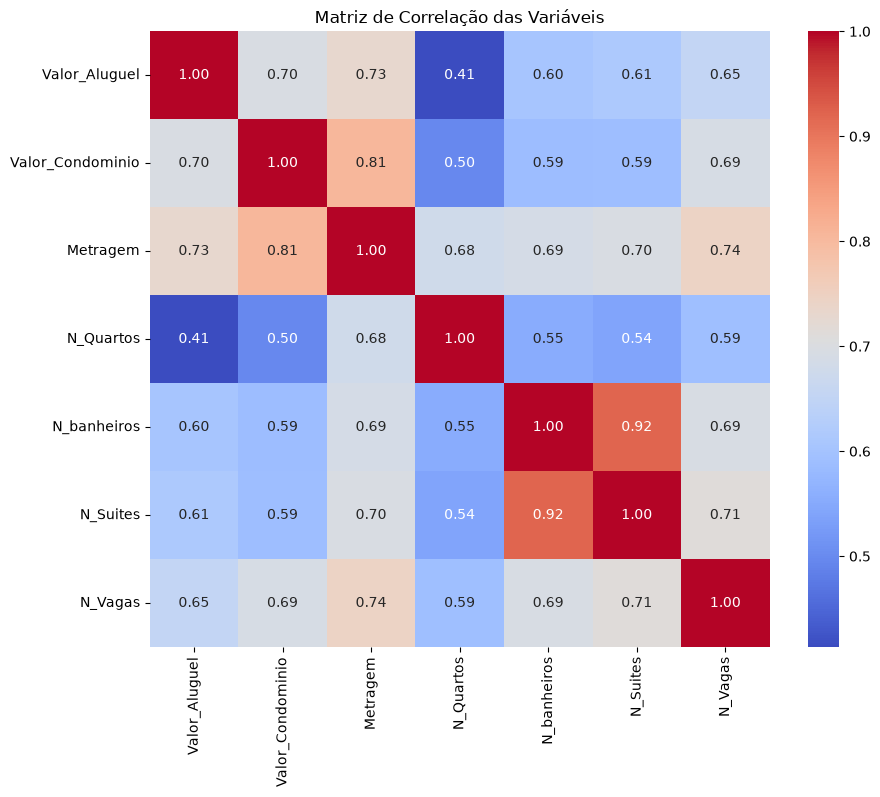

In [63]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação das Variáveis')
plt.show()

#Análise da correlação:
A matriz de correlação mostra que Metragem apresenta a correlação mais forte com Valor_Aluguel (0,73), seguida por Valor_Condominio (0,70) e N_Vagas (0,65). N_Suites (0,61) e N_banheiros (0,60) também apresentam correlações positivas relevantes, enquanto N_Quartos possui a menor correlação com a variável-alvo (0,41). Portanto, Metragem, Valor_Condominio e N_Vagas parecem ser inicialmente as variáveis mais fortes para explicar o valor do aluguel. Também foi identificada uma correlação elevada entre N_banheiros e N_Suites (0,92), indicando possível multicolinearidade entre essas variáveis.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [68]:
# Separando as variáveis independentes (X) e dependente (y)
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']

# Importando a função para divisão dos dados
from sklearn.model_selection import train_test_split

# Separando os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Verificando as dimensões
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (5762, 6)
X_test: (1441, 6)
y_train: (5762,)
y_test: (1441,)


Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

# 4 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [69]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [72]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[34.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Metragem']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [75]:
print('Intercepto:', modelo.intercept_)
print('Coeficiente:', modelo.coef_[0])

print(
    f'Equação da reta: Valor_Aluguel = '
    f'{modelo.intercept_:.2f} + '
    f'{modelo.coef_[0]:.2f} × Metragem'
)
      

Intercepto: -96.99896039932173
Coeficiente: 34.47397089324872
Equação da reta: Valor_Aluguel = -97.00 + 34.47 × Metragem


#O modelo de regressão linear simples resultou na equação Valor_Aluguel = -97,00 + 34,47 × Metragem. O coeficiente indica que, para cada aumento de 1 m² na metragem do imóvel, o modelo estima um aumento médio de aproximadamente R$ 34,47 no valor do aluguel. O intercepto de -R$ 97,00 representa matematicamente o valor estimado quando a metragem é zero, não possuindo interpretação prática relevante neste contexto.

Nossa equação seria:  

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [76]:
r2_treino = modelo.score(X, y)

print(f'R² do treinamento: {r2_treino:.4f}')
print(f'Percentual explicado pelo modelo: {r2_treino * 100:.2f}%')

R² do treinamento: 0.5214
Percentual explicado pelo modelo: 52.14%


#Insight: O modelo apresentou um R² de 0,5214, indicando que aproximadamente 52,14% da variação do valor do aluguel é explicada pela metragem do imóvel no conjunto de treinamento. O resultado demonstra que a metragem possui um poder explicativo relevante, porém moderado. Os 47,86% restantes da variação podem estar relacionados a outras características dos imóveis que não foram consideradas neste modelo de regressão linear simples. Portanto, a inclusão de outras variáveis relevantes poderá aumentar a capacidade explicativa do modelo.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

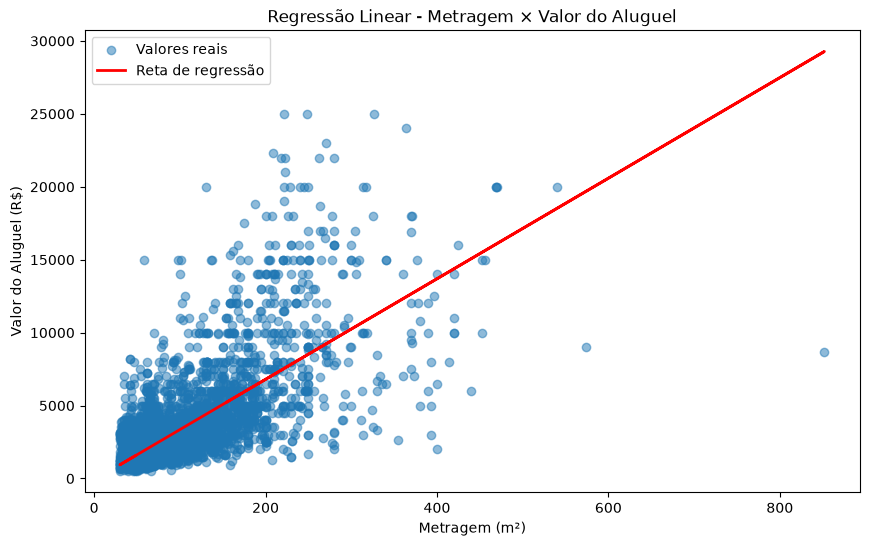

In [79]:
# Gerando as previsões
y_pred = modelo.predict(X)

# Plotando os dados e a reta
plt.figure(figsize=(10, 6))

plt.scatter(
    X['Metragem'],
    y,
    alpha=0.5,
    label='Valores reais'
)

plt.plot(
    X['Metragem'],
    y_pred,
    color='red',
    linewidth=2,
    label='Reta de regressão'
)

plt.title('Regressão Linear - Metragem × Valor do Aluguel')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel (R$)')
plt.legend()

plt.show()

#Insight: O gráfico apresenta uma tendência linear positiva entre a metragem e o valor do aluguel, indicando que imóveis maiores tendem a possuir valores de aluguel mais elevados. Entretanto, observa-se uma dispersão considerável dos pontos em torno da reta de regressão, principalmente para imóveis de maior metragem. Esse comportamento está de acordo com o R² de 0,5214 obtido no treinamento, indicando que a metragem explica aproximadamente 52,14% da variação do valor do aluguel. Também são observados alguns valores extremos, tanto de metragem quanto de aluguel, que podem influenciar o ajuste da reta. Portanto, embora a metragem seja uma variável relevante, outras características dos imóveis devem contribuir para explicar o valor do aluguel.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [82]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [83]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
# Selecionando no teste a mesma variável utilizada no treinamento
X_test = X_test[['Metragem']]

# Fazendo previsões nos dados de teste
previsoes = modelo.predict(X_test)

# Calculando o R² nos dados de teste
r2_teste = modelo.score(X_test, y_test)

print(f'R² do teste: {r2_teste:.4f}')
print(f'Percentual explicado no teste: {r2_teste * 100:.2f}%')


R² do teste: 0.5698
Percentual explicado no teste: 56.98%


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.

#Insight: O modelo apresentou R² de 0,5698 nos dados de teste, indicando que aproximadamente 56,98% da variação do valor do aluguel é explicada pela metragem em dados que não foram utilizados durante o treinamento. Comparando com o R² de treinamento de 0,5214 (52,14%), observa-se um desempenho semelhante e até ligeiramente superior no conjunto de teste, não havendo evidência clara de overfitting. Entretanto, o poder explicativo ainda pode ser considerado moderado, indicando que somente a metragem não é suficiente para explicar toda a variação do valor do aluguel e que outras características dos imóveis podem contribuir para melhorar o modelo.

# 5 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [84]:
# Separando todas as variáveis independentes
X = df.drop('Valor_Aluguel', axis=1)

# Separando a variável dependente
y = df['Valor_Aluguel']

# Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Conferindo as dimensões
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (5762, 6)
X_test: (1441, 6)
y_train: (5762,)
y_test: (1441,)


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [85]:
# Criando o modelo de regressão linear múltipla
from sklearn.linear_model import LinearRegression

modelo_multiplo = LinearRegression()

# Treinando o modelo somente com os dados de treino
modelo_multiplo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.78, 20.68,-649.12, 223.71, 340.34, 501.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Valor_Condominio','Metragem','N_Quartos','N_banheiros','N_Suites', 'N_Vagas']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,435.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [86]:
print('Intercepto:', modelo_multiplo.intercept_)
print('Coeficientes:', modelo_multiplo.coef_)

Intercepto: 435.292731560663
Coeficientes: [   0.78400678   20.68135689 -649.12188657  223.71153486  340.33788484
  501.24631769]


In [ ]:
# Visualizando o coeficiente de maneira mais clara
coeficientes = pd.DataFrame({
    'Variável': X_train.columns,
    'Coeficiente': modelo_multiplo.coef_
})

coeficientes

,Variável,Coeficiente
0,Valor_Condominio,0.784007
1,Metragem,20.681357
2,N_Quartos,-649.121887
3,N_banheiros,223.711535
4,N_Suites,340.337885
5,N_Vagas,501.246318


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [88]:
r2_multiplo_treino = modelo_multiplo.score(X_train, y_train)

print(f'R² do treinamento: {r2_multiplo_treino:.4f}')
print(f'Percentual explicado pelo modelo: {r2_multiplo_treino * 100:.2f}%')

R² do treinamento: 0.5958
Percentual explicado pelo modelo: 59.58%


#Insight: O modelo de regressão linear múltipla apresentou um R² de 0,5958, indicando que aproximadamente 59,58% da variação do valor do aluguel é explicada conjuntamente pelas variáveis utilizadas no modelo. Em comparação com a regressão linear simples, que apresentou R² de 52,14%, houve um aumento de 7,44 pontos percentuais no poder explicativo. Portanto, a inclusão das demais características dos imóveis melhorou o desempenho do modelo, embora aproximadamente 40,42% da variabilidade do valor do aluguel ainda permaneça não explicada.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [89]:
# Fazendo previsões na base de teste
previsoes_multiplo = modelo_multiplo.predict(X_test)

# Calculando o R² na base de teste
r2_multiplo_teste = modelo_multiplo.score(X_test, y_test)

print(f'R² do teste: {r2_multiplo_teste:.4f}')
print(f'Percentual explicado no teste: {r2_multiplo_teste * 100:.2f}%')

R² do teste: 0.6401
Percentual explicado no teste: 64.01%


#Insight: O modelo de regressão linear múltipla apresentou R² de 0,6401 na base de teste, indicando que aproximadamente 64,01% da variação do valor do aluguel foi explicada pelas variáveis utilizadas no modelo. O resultado foi superior ao R² de treinamento, de 59,58%, e não apresenta evidência clara de overfitting nesta divisão dos dados. Além disso, o modelo múltiplo apresentou desempenho superior à regressão linear simples tanto no treinamento quanto no teste, indicando que a inclusão das demais características dos imóveis aumentou a capacidade explicativa do modelo.

E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui

#Conclusão dos modelos:

O resultado do exercício ficou bastante coerente.

Regressão simples
Metragem → 56,98% no teste

Regressão múltipla
6 características → 64,01% no teste

Portanto, para esta base e esta divisão treino/teste, o modelo de regressão múltipla apresentou melhor poder explicativo.

Isso também confirma conforme observamos inicialmente que, a metragem é importante, mas o valor do aluguel depende de várias características do imóvel, não apenas do tamanho.